In [1]:
import pandas as pd

site_number = '90069'
bisection = pd.read_csv(f'output_site_{site_number}_bisection.csv')
data_49 = pd.read_csv(f'output_site_{site_number}_49.csv')
data_60 = pd.read_csv(f'output_site_{site_number}_60.csv')
nonlinear = pd.read_csv(f'output_site_{site_number}_nonlinear.csv')
load_shift = pd.read_csv(f'output_site_{site_number}_load_shifting.csv')
bisection 


,Hot Water Outlet Temperature (C),T_WH3,T_WH10,Water Heating Heat Pump COP (-),Water Heating Mode,Water Heating Electric Power (kWh),Hot Water Delivered (kWh),Hot Water Heat Loss (kWh),Hot Water Heat Injected (kWh),Hot Water Unmet Demand (kWh),Draw Data,Setpoints
0,50.793497,50.867732,50.867732,4.423562,Off,0.00025,0.000000,0.016759,0.0,0.0,0.00000,49.0
1,50.727607,50.784989,50.785739,4.432140,Off,0.00025,0.000000,0.016705,0.0,0.0,0.00000,49.0
2,50.566594,50.702008,50.703939,4.440715,Off,0.00025,0.000000,0.016649,0.0,0.0,0.00000,49.0
3,50.574267,50.595401,50.622056,4.451370,Off,0.00025,0.000000,0.016595,0.0,0.0,0.00000,49.0
4,50.414811,50.514142,50.539652,4.459931,Off,0.00025,0.000000,0.016543,0.0,0.0,0.00000,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...
18906,50.067720,50.229053,49.702881,4.819983,Off,0.00025,0.000000,0.013981,0.0,0.0,0.00000,49.0
18907,50.070248,50.116934,49.541344,4.833163,Off,0.00025,0.000000,0.013952,0.0,0.0,0.00000,49.0
18908,50.019885,50.036939,47.763465,5.024358,Off,0.00025,0.147592,0.013688,0.0,0.0,3.78541,49.0
18909,49.862156,49.956047,47.588043,5.035598,Off,0.00025,0.000000,0.013356,0.0,0.0,0.00000,49.0


In [ ]:
#Comparing heat loss 
import pandas as pd
import numpy as np

def get_daily_kWh(data):
    energy = data["Water Heating Electric Power (kWh)"] #15 minute intervals of kwh
    day_sums = energy.groupby(energy.index // 96).sum().tolist()
    return (np.mean(day_sums))

def return_unmet_draws(data, min = 40.6):
    #data["Hot Water Outlet Temperature (C)"] = (pd.to_numeric(data["Hot Water Outlet Temperature (C)"], errors="coerce"))
    draws = data["Hot Water Outlet Temperature (C)"].values
    cold_water_draws = sum(float(i) < min for i in draws)
    return cold_water_draws/len(draws) * 100

dt = 1 # seconds in each 15-minute interval
#E_electric = E_delivered + E_loss + other
def total_loss_kWh(data):
    # 15-minute intervals
    return np.sum(data["Hot Water Heat Loss (kWh)"]*dt) 

def total_electric_kWh(data):
    return np.sum(data["Hot Water Heat Injected (kWh)"]*dt)

def total_heat_pump_electric_kWh(data):
    return np.sum(data["Water Heating Electric Power (kWh)"]*dt)
#sites = [22096]

sites = [ 90069
]


unmet_draws = []
daily_kWh = []
net_savings = []
avg_draw = []
net_injection_savings = []
net_loss_savings = []

for site_number in sites:
    print(site_number)
    #Comparing standard performance to 40 G bisection controller

    min_temp = 40.6

    elevated = pd.read_csv(f'output_site_{site_number}_60.csv')

    baseline_og = None
 
    bisection = pd.read_csv(f"output_site_90069_bisection.csv")

    print("Bisection", return_unmet_draws(bisection, min_temp), get_daily_kWh(bisection), np.sum(bisection["Water Heating Electric Power (kWh)"])) #100 days
    print("Baseline (Elevated) ", return_unmet_draws(elevated, min_temp), get_daily_kWh(elevated), np.sum(elevated["Water Heating Electric Power (kWh)"])) #365 days
    print("Net savings: ", 1 - np.sum(bisection["Water Heating Electric Power (kWh)"])/np.sum(elevated["Water Heating Electric Power (kWh)"]))
    draw = elevated['Draw Data']
    draw = draw[:-95] #removing last day to keep indices exact
    daily_avg = np.sum(np.asarray(draw).reshape(-1, 96), axis=1)
    avg_draw.append(daily_avg.mean()) #avg L per day
    unmet_draws.append([return_unmet_draws(elevated, min_temp), return_unmet_draws(bisection, min_temp) ])
    daily_kWh.append([get_daily_kWh(elevated),get_daily_kWh(bisection)  ])
    net_savings.append(np.sum(elevated["Water Heating Electric Power (kWh)"]) - np.sum(bisection["Water Heating Electric Power (kWh)"]) )
    #print(return_unmet_draws(bisection_ideal, min_temp), get_daily_kWh(bisection_ideal), np.sum(bisection_ideal["Water Heating Electric Power"])) #100 days
 

    #Compute total loss and kwh of elevated and bisection
    elevated_loss_kWh   = total_loss_kWh(elevated)
    bisection_loss_kWh  = total_loss_kWh(bisection)
    elevated_delivered = np.sum(elevated["Hot Water Delivered (kWh)"]*dt) 
    bisection_delivered = np.sum(bisection["Hot Water Delivered (kWh)"]*dt) 

    elevated_elec_kWh  = total_electric_kWh(elevated)
    bisection_elec_kWh = total_electric_kWh(bisection)

    # Absolute savings
    total_savings_kWh = elevated_elec_kWh - bisection_elec_kWh
    loss_savings_kWh  = elevated_loss_kWh - bisection_loss_kWh

    net_injection_savings.append(elevated_elec_kWh - bisection_elec_kWh)
    net_loss_savings.append((elevated_loss_kWh - bisection_loss_kWh))

    print("Elevated Electric = ", elevated_elec_kWh, " (Injected) ~ ", elevated_delivered, " (delivered) + ", elevated_loss_kWh, "(loss) = ", elevated_delivered + elevated_loss_kWh, " unaccounted: ", elevated_elec_kWh - (elevated_delivered + elevated_loss_kWh))
    print("Bisection Electric = ", bisection_elec_kWh, " (Injected) ~ ", bisection_delivered, " (delivered) + ", bisection_loss_kWh, "(loss) = ", bisection_delivered + bisection_loss_kWh, " unaccounted: ", bisection_elec_kWh - (bisection_delivered + bisection_loss_kWh))
    print(f"Difference in Losses (kWh): {total_savings_kWh:.2f}")
    print(f"Difference in Electric (kWh): {loss_savings_kWh:.2f}")
    print(f"Injection Savings (kWh): {(1 - bisection_elec_kWh/elevated_elec_kWh)* 100} %")
    print(f"Electric Savings (kWh): {(1 - total_heat_pump_electric_kWh(bisection)/total_heat_pump_electric_kWh(elevated))* 100} %")
    print(f"Loss Savings (kWh): {(1 - bisection_loss_kWh/elevated_loss_kWh) * 100} %")






90069
Bisection 0.015704339632518452 1.297863495022236 258.2748355094249
Baseline (Elevated)  0.0 1.583782341628132 315.1726859839982
Net savings:  0.18052912896602358
Elevated Electric =  1450.3610345239094  (Injected) ~  1129.521327764081  (delivered) +  321.4033448138807 (loss) =  1450.9246725779617  unaccounted:  -0.5636380540522623
Bisection Electric =  1363.4834059024784  (Injected) ~  1129.5208965944955  (delivered) +  234.5707527678287 (loss) =  1364.0916493623242  unaccounted:  -0.6082434598458804
Difference in Losses (kWh): 86.88
Difference in Electric (kWh): 86.83
Injection Savings (kWh): 5.990069131300757 %
Electric Savings (kWh): 18.052912896602358 %
Loss Savings (kWh): 27.016704538758084 %


In [5]:
import matplotlib.pyplot as plt

sites = ['11531', '13438', '22096', '23744', '90015', '90069' ]
for site in sites:
    #plot bargraph for water heating electric power
    print("Water Heating Electric Power (kWh)")
    print(sum(bisection['Water Heating Electric Power (kWh)']))
    print(sum(nonlinear['Water Heating Electric Power (kWh)']))
    print(sum(data_49['Water Heating Electric Power (kWh)']))
    print(sum(data_60['Water Heating Electric Power (kWh)']))
    print(sum(load_shift['Water Heating Electric Power (kWh)']))

    print("Unmet Demand")
    print(sum(bisection['Hot Water Unmet Demand (kWh)']))
    print(sum(nonlinear['Hot Water Unmet Demand (kWh)']))
    print(sum(data_49['Hot Water Unmet Demand (kWh)']))
    print(sum(data_60['Hot Water Unmet Demand (kWh)']))
    print(sum(load_shift['Hot Water Unmet Demand (kWh)']))



Water Heating Electric Power (kWh)
599.4443257588694
253.995161366036
587.8250114733855
712.4180816151413
625.1508822110874
Unmet Demand
194.25870995669672
0.0
196.63685356622187
78.8629691376593
203.0865950269989


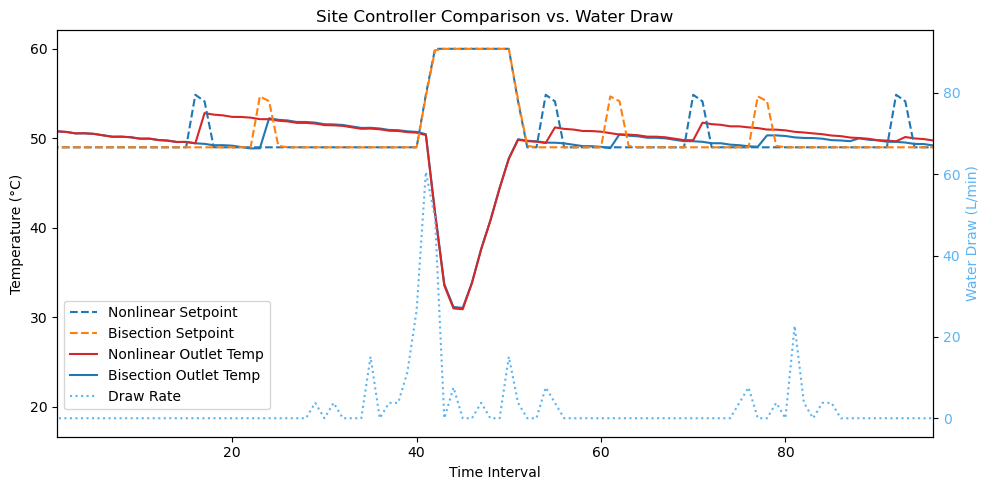

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

site = '90069'
nonlinear = pd.read_csv(f'output_site_{site}_nonlinear.csv')
bisection = pd.read_csv(f'output_site_{site}_bisection.csv')[0:len(nonlinear)]    

fig, ax1 = plt.subplots(figsize=(10, 5))

# --- Left Y-Axis: Temperatures / Setpoints ---
line5, = ax1.plot(bisection["Hot Water Outlet Temperature (C)"], label="Bisection Outlet Temp", color="tab:blue")
line4, = ax1.plot(nonlinear["Hot Water Outlet Temperature (C)"], label="Nonlinear Outlet Temp", color="tab:red")
line1, = ax1.plot(nonlinear['Setpoints'], label="Nonlinear Setpoint", color="tab:blue", linestyle="dashed")
line2, = ax1.plot(bisection['Setpoints'], label="Bisection Setpoint", color="tab:orange", linestyle="dashed")

ax1.set_ylabel("Temperature (°C)")
ax1.set_xlabel("Time Interval")
ax1.set_xlim(0, 96)  # Restrict to first 96 intervals (0-indexed)

water_color = "#5BB4F3"
# --- Right Y-Axis: Water Draw ---
ax2 = ax1.twinx()  # Fix: twinx() for secondary vertical Y-axis
line3, = ax2.plot(bisection['Draw Data'], label="Draw Rate", color=water_color, linestyle="dotted")
ax2.set_ylabel("Water Draw (L/min)", color=water_color)
ax2.tick_params(axis='y', labelcolor=water_color)

# --- Combined Legend ---
lines = [line1, line2, line4, line5, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best", bbox_to_anchor=(0, 0.05, 1, 1))

plt.xlim(1, 96)
plt.title(f"Site Controller Comparison vs. Water Draw")
plt.tight_layout()
plt.show()

## Create Comparison Graphs for Ecotope Sites
### Unmet Demand/ kWh usage

Site 13438: 3794.30 L/Day
Site 90069: 5895.93 L/Day


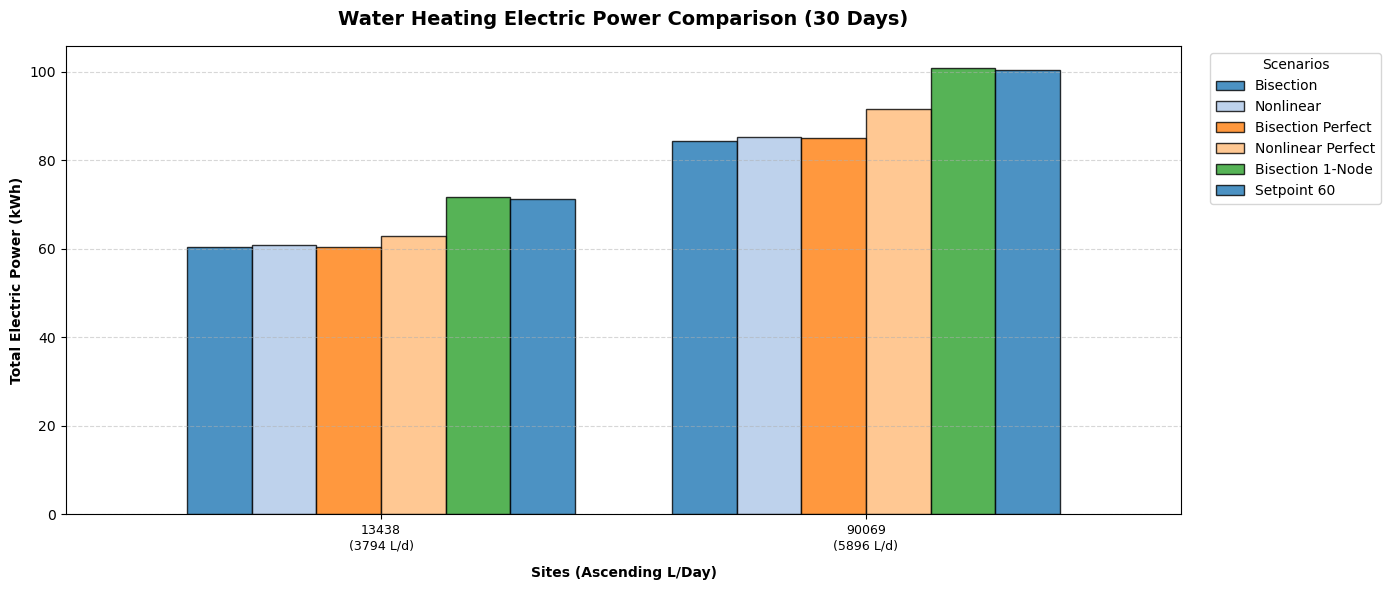

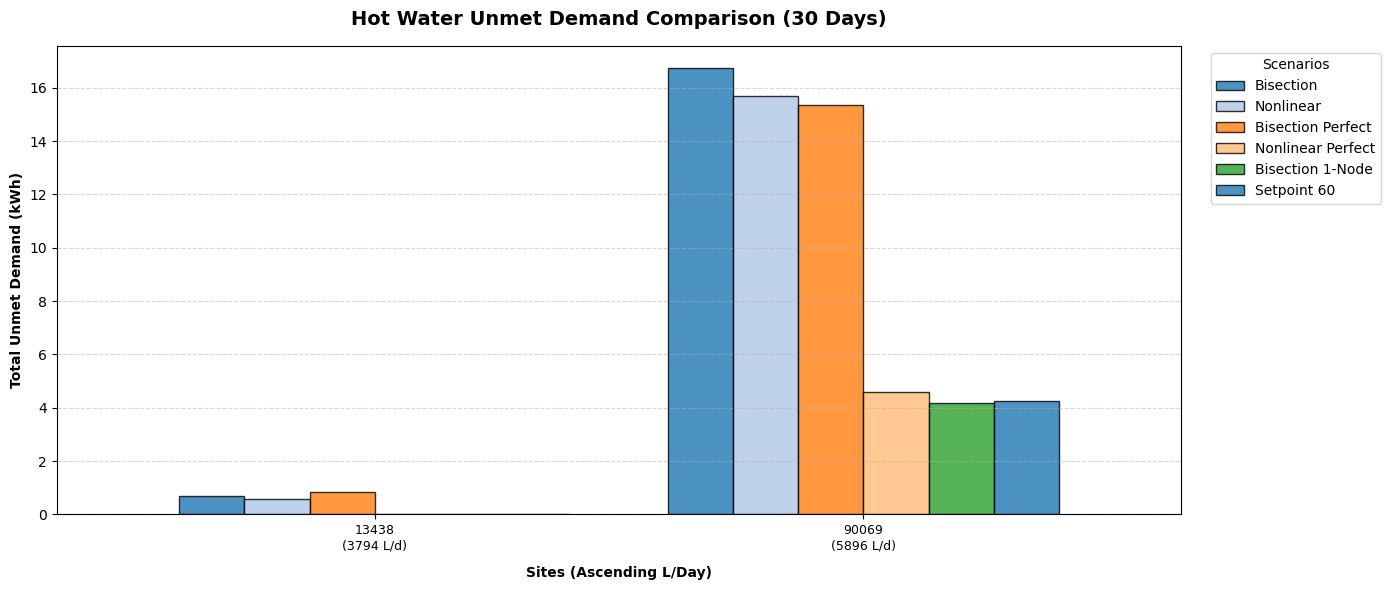

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sites = [22096, 13438,
     11531, 23744, 11289, 13265, 23666, 
    90028, 90050, 90135, 10441, 90015, 90030,
    21578, 22897, 90023, 90130, 99094, 90051,
     90131, 90034, 99148, 99162, 99103,
    99092, 99084
]

#22096
sites = [13438, 90069]

scenarios = ['Bisection', 'Nonlinear', 'Setpoint 49', 'Setpoint 60', 'Load Shift']

power_data = []
unmet_data = []
draw_data = {}  # Store average daily draw per site

for site in sites:
    #if site in [90069, 90130, 21578, 90023, 90051, 90131, 90034]: #"good test sites"
    try:
        nonlinear = pd.read_csv(f'output_site_{site}_nonlinear.csv')
        bisection = pd.read_csv(f'output_site_{site}_bisection.csv')[0:len(nonlinear)]            
        bisection_perfect = pd.read_csv(f'output_site_{site}_bisection_perfect.csv')[0:len(nonlinear)]    
        nonlinear_perfect = pd.read_csv(f'timestep_log_site_{site}_nonlinear_perfect.csv')
        bisection_1node = pd.read_csv(f'output_site_{site}_bisection_rolling_1.csv')[0:len(nonlinear)]
        #data_49 = pd.read_csv(f'output_site_{site}_49.csv')[0:len(nonlinear)]
        data_60 = pd.read_csv(f'output_site_{site}_60.csv')[0:len(nonlinear)]
        #load_shift = pd.read_csv(f'output_site_{site}_load_shifting.csv')[0:len(nonlinear)]
    except Exception as e:
        print(f"Skipping site {site}: {e}")
        continue

    # Calculate L/Day from bisection dataset
    daily_draw = sum(bisection['Draw Data']) / (len(bisection) / 1440)
    draw_data[site] = daily_draw
    print(f"Site {site}: {daily_draw:.2f} L/Day")

    power_data.append({
        'Site': site,
        'Bisection': bisection['Water Heating Electric Power'].sum(),
        'Nonlinear': nonlinear['Water Heating Electric Power'].sum(),
        'Bisection Perfect': bisection_perfect['Water Heating Electric Power'].sum(),
        'Nonlinear Perfect': nonlinear_perfect['Energy (kWh)'].sum(),
        'Bisection 1-Node': bisection_1node['Water Heating Electric Power'].sum(),
        #'Setpoint 49': data_49['Water Heating Electric Power'].sum(),
        'Setpoint 60': data_60['Water Heating Electric Power'].sum(),
        #'Load Shift': load_shift['Water Heating Electric Power'].sum()
    })

    unmet_data.append({
        'Site': site,
        'Bisection': bisection['Hot Water Unmet Demand (kWh)'].sum(),
        'Nonlinear': nonlinear['Hot Water Unmet Demand (kWh)'].sum(),
        'Bisection Perfect': bisection_perfect['Hot Water Unmet Demand (kWh)'].sum(),
        'Nonlinear Perfect': nonlinear_perfect['Hot Water Unmet Demand (kWh)'].sum(),
        'Bisection 1-Node': bisection_1node['Hot Water Unmet Demand (kWh)'].sum(),
        #'Setpoint 49': data_49['Hot Water Unmet Demand (kWh)'].sum(),
        'Setpoint 60': data_60['Hot Water Unmet Demand (kWh)'].sum(),
        #'Load Shift': load_shift['Hot Water Unmet Demand (kWh)'].sum()
    })

# Convert to DataFrames and set index
df_power = pd.DataFrame(power_data).set_index('Site')
df_unmet = pd.DataFrame(unmet_data).set_index('Site')

# Sort sites in ascending order of daily water draw (L/Day)
sorted_sites = sorted(draw_data.keys(), key=lambda s: draw_data[s])

# Reindex DataFrames to reflect the sorted site order
df_power = df_power.reindex(sorted_sites)
df_unmet = df_unmet.reindex(sorted_sites)

# Update x-axis labels to include L/Day for clarity (Optional: omit if you prefer just site IDs)
x_labels = [f"{site}\n({draw_data[site]:.0f} L/d)" for site in sorted_sites]

colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c']

# ==========================================
# GRAPH 1: Water Heating Electric Power
# ==========================================
ax1 = df_power.plot(kind='bar', figsize=(14, 6), color=colors, width=0.8, edgecolor='black', alpha=0.8)
plt.title('Water Heating Electric Power Comparison (30 Days)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sites (Ascending L/Day)', fontweight='bold', labelpad=10)
plt.ylabel('Total Electric Power (kWh)', fontweight='bold')
plt.xticks(ticks=range(len(sorted_sites)), labels=x_labels, rotation=0, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Scenarios', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 2: Hot Water Unmet Demand
# ==========================================
ax2 = df_unmet.plot(kind='bar', figsize=(14, 6), color=colors, width=0.8, edgecolor='black', alpha=0.8)
plt.title('Hot Water Unmet Demand Comparison (30 Days)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sites (Ascending L/Day)', fontweight='bold', labelpad=10)
plt.ylabel('Total Unmet Demand (kWh)', fontweight='bold')
plt.xticks(ticks=range(len(sorted_sites)), labels=x_labels, rotation=0, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Scenarios', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

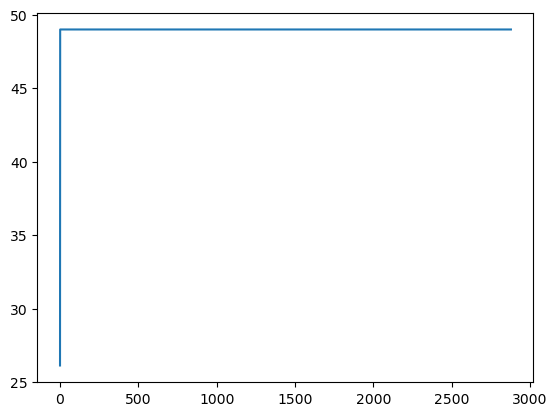

In [4]:
plt.plot(nonlinear['Setpoints'])

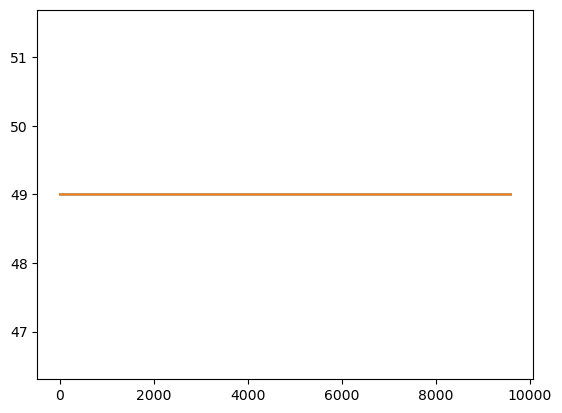

In [23]:
site = 90034
nonlinear = pd.read_csv(f'output_site_{site}_nonlinear.csv')
bisection = pd.read_csv(f'output_site_{site}_bisection.csv')
import matplotlib.pyplot as plt

plt.plot(nonlinear['Setpoints'])
plt.plot(bisection['Setpoints'])
#plt.plot(bisection['Draw Data'])


In [ ]:
import 

,Hot Water Outlet Temperature (C),T_WH3,T_WH10,Water Heating Heat Pump COP (-),Water Heating Mode,Water Heating Electric Power (kWh),Hot Water Delivered (kWh),Hot Water Heat Loss (kWh),Hot Water Heat Injected (kWh),Hot Water Unmet Demand (kWh),Draw Data,Setpoints
0,50.844331,50.899874,50.899874,4.420265,Off,0.00025,0.000000,0.016769,0.0,0.0,0.00000,49.0
1,50.830502,50.851936,50.852182,4.425321,Off,0.00025,0.000000,0.016735,0.0,0.0,11.35623,49.0
2,50.711143,50.803635,50.662358,4.571044,Off,0.00025,0.442776,0.015796,0.0,0.0,0.00000,49.0
3,50.605184,50.755353,50.585712,4.579538,Off,0.00025,0.000000,0.015254,0.0,0.0,0.00000,49.0
4,50.633468,50.684711,50.508097,4.588352,Off,0.00025,0.000000,0.015237,0.0,0.0,0.00000,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9594,52.389041,52.468046,33.455412,5.923056,Off,0.00025,0.000000,0.011855,0.0,0.0,0.00000,51.5
9595,52.358782,52.417282,33.404332,5.926088,Off,0.00025,0.000000,0.011841,0.0,0.0,0.00000,51.5
9596,52.246356,52.366200,33.354040,5.929093,Off,0.00025,0.000000,0.011825,0.0,0.0,0.00000,51.5
9597,52.263942,52.263942,33.304524,5.932071,Off,0.00025,0.000000,0.011809,0.0,0.0,0.00000,51.5


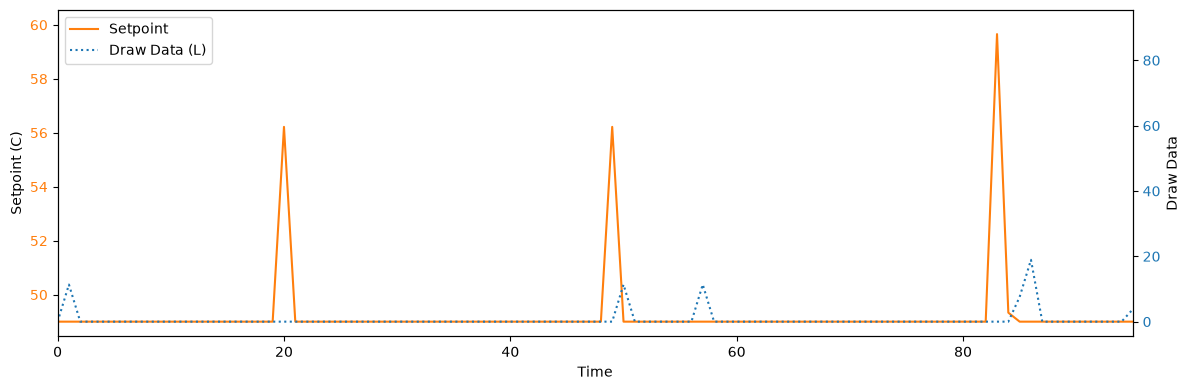

In [8]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(bisection['Setpoints'], label='Setpoint', color='tab:orange')
ax1.set_ylabel('Setpoint (C)')
# ax1.plot(bisection['Water Heating Electric Power (kWh)'], label='KWh', color='tab:orange')
# ax1.set_ylabel('Water Heating Electric Power (kWh)')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='tab:orange')

ax2 = ax1.twinx()
ax2.plot(bisection['Draw Data'], label='Draw Data (L)', linestyle='dotted', color='tab:blue')
ax2.set_ylabel('Draw Data')
ax2.tick_params(axis='y', labelcolor='tab:blue')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
plt.xlim(0, 95)
plt.tight_layout()
plt.show()
